In [1]:
!pip install yfinance pandas-gbq -q
!pip install mlflow pyngrok --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.5/901.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
from google.colab import auth
auth.authenticate_user()

In [40]:
from google.cloud import bigquery
client = bigquery.Client(project="stock-predictor-496217")
df = client.query("SELECT * FROM stocks_data.features").to_dataframe()

In [41]:
import pandas as pd
import numpy as np
import xgboost as xgb
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

## Tratamento dos dados

In [42]:
df.head()

,Date,Close,High,Low,Open,Volume,ticker,SPY_return,VIX_close,RSI,...,return_1,return_5,return_10,EMA_9,EMA_21,EMA_50,trend,volatility,bull_market,target
0,2010-02-02,5.863152,5.876923,5.788912,5.864649,698342400,AAPL,0.012104,21.48,39.023319,...,0.005803,-0.048947,-0.089193,5.986052,6.087427,6.142478,0,0.022815,0,0
1,2010-02-02,5.906000,5.949000,5.720000,5.939500,461594000,AMZN,0.012104,21.48,37.662650,...,-0.006309,-0.011383,-0.074367,6.114154,6.212912,6.276854,0,0.021093,0,0
2,2010-02-02,13.182340,13.277648,13.095222,13.277648,163684152,GOOGL,0.012104,21.48,15.951672,...,-0.003565,-0.020832,-0.096151,13.492418,13.847201,14.072812,0,0.016089,0,0
3,2010-02-02,21.174889,21.204650,20.936802,21.107928,54413700,MSFT,0.012104,21.48,31.616426,...,0.001760,-0.035254,-0.084888,21.620163,21.973917,22.167827,0,0.014869,0,0
4,2010-02-02,0.383675,0.388488,0.377257,0.378403,849812000,NVDA,0.012104,21.48,52.214834,...,0.010260,0.032696,-0.039587,0.379226,0.387212,0.393007,0,0.028827,0,0


In [43]:
print(f"Ações: {df['ticker'].unique()} \n" )

Ações: ['AAPL' 'AMZN' 'GOOGL' 'MSFT' 'NVDA'] 



In [44]:
df = df.dropna()

## Pré-treinamento

In [45]:
target1 = 0
target0 = 0

for i in df['target']:
  if i == 1:
    target1+=1
  else:
    target0+=1

print(f"Existem {target1} de target 1")
print(f"Existem {target0} de target 0")
print(f"Existem {df.shape} de dados")

Existem 5033 de target 1
Existem 15477 de target 0
Existem (20510, 25) de dados


## Processamento dos dados

In [46]:
df = df.drop(columns=['target'])

df['target'] = df.groupby('ticker')['Close'].transform(
    lambda x: ((x.shift(-1) / x - 1) > 0.005).astype(int)
)

df = df.dropna(subset=['target'])

for ticker in df['ticker'].unique():
    print(f"{ticker} → target: {df[df['ticker']==ticker]['target'].value_counts().to_dict()}")

AAPL → target: {0: 2504, 1: 1598}
AMZN → target: {0: 2463, 1: 1639}
GOOGL → target: {0: 2543, 1: 1559}
MSFT → target: {0: 2621, 1: 1481}
NVDA → target: {0: 2346, 1: 1756}


In [47]:
column_drop = ["Date", 'Close', 'ticker']
lookback= 60


X_trains, X_vals, X_tests = [], [], []
y_trains, y_vals, y_tests = [], [], []

for ticker in df['ticker'].unique():
    df_t = df[df['ticker'] == ticker].copy()

    # Remove último dia de cada ticker (NaN do shift(-1))
    df_t = df_t.iloc[:-1]

    X_t = df_t.drop(columns=column_drop).values
    y_t = df_t['target'].values

    # Split temporal
    train_end = int(len(X_t) * 0.60)
    val_end   = int(len(X_t) * 0.70)

    X_tr, y_tr = X_t[:train_end],        y_t[:train_end]
    X_v,  y_v  = X_t[train_end:val_end], y_t[train_end:val_end]
    X_te, y_te = X_t[val_end:],          y_t[val_end:]

    # Normaliza
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_v  = scaler.transform(X_v)
    X_te = scaler.transform(X_te)

    # Janelas por ticker separado
    for i in range(lookback, len(X_tr)):
        X_trains.append(X_tr[i-lookback:i])
        y_trains.append(y_tr[i])

    for i in range(lookback, len(X_v)):
        X_vals.append(X_v[i-lookback:i])
        y_vals.append(y_v[i])

    for i in range(lookback, len(X_te)):
        X_tests.append(X_te[i-lookback:i])
        y_tests.append(y_te[i])

X_train_lstm = np.array(X_trains)
X_val_lstm   = np.array(X_vals)
X_test_lstm  = np.array(X_tests)

y_train_lstm = np.array(y_trains)
y_val_lstm   = np.array(y_vals)
y_test_lstm  = np.array(y_tests)

# Verifica
print(f"Target treino:    {y_train_lstm.mean():.2f}")
print(f"Target validação: {y_val_lstm.mean():.2f}")
print(f"Target teste:     {y_test_lstm.mean():.2f}")
print(f"Shape treino:     {X_train_lstm.shape}")

Target treino:    0.39
Target validação: 0.35
Target teste:     0.41
Shape treino:     (12000, 60, 22)


In [48]:
df['EMA_9_rel']  = df['Close'] / df['EMA_9'] - 1
df['EMA_21_rel'] = df['Close'] / df['EMA_21'] - 1
df['EMA_50_rel'] = df['Close'] / df['EMA_50'] - 1
df['BB_upper_rel'] = df['Close'] / df['BB_upper'] - 1
df['BB_lower_rel'] = df['Close'] / df['BB_lower'] - 1
df['Open_rel']  = df['Open']  / df['Close'] - 1
df['High_rel']  = df['High']  / df['Close'] - 1
df['Low_rel']   = df['Low']   / df['Close'] - 1

df['SPY_return_5'] = df['SPY_return'].rolling(5).sum()
df['VIX_return'] = df['VIX_close'] / df['VIX_close'].shift(1) - 1

df.drop(columns=['EMA_9', 'EMA_21', 'EMA_50', 'BB_upper', 'BB_lower'], inplace=True)
df.drop(columns=['Close', 'Open', 'High', 'Low'], inplace=True)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
  )

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

classes = np.unique(y_train_lstm)
weights = compute_class_weight('balanced', classes=classes, y=y_train_lstm)
class_weight = dict(zip(classes, weights))
print(class_weight)


{np.int64(0): np.float64(0.8206811653672548), np.int64(1): np.float64(1.2795905310300704)}


## Salvamento das versões de treino

In [13]:
mlflow.set_experiment("stock-predictor")

with mlflow.start_run(run_name="lstm_xgb_v1"):

    # ── Hiperparâmetros ── #
    lstm_units_1  = 64
    lstm_units_2  = 32
    dropout       = 0.3
    epochs        = 200
    batch_size    = 64
    xgb_estimators = 500
    xgb_lr        = 0.02
    depth         = 4

    mlflow.log_param("lookback",       lookback)
    mlflow.log_param("lstm_units_1",   lstm_units_1)
    mlflow.log_param("lstm_units_2",   lstm_units_2)
    mlflow.log_param("dropout",        dropout)
    mlflow.log_param("epochs",         epochs)
    mlflow.log_param("batch_size",     batch_size)
    mlflow.log_param("xgb_estimators", xgb_estimators)
    mlflow.log_param("xgb_lr",         xgb_lr)

2026/05/25 12:48:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 12:48:25 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 12:48:27 INFO mlflow.tracking.fluent: Experiment with name 'stock-predictor' does not exist. Creating a new experiment.


### Criação do Modelo LSTM

In [14]:
modelo_lstm = Sequential([
    LSTM(lstm_units_1, input_shape=(lookback, X_train_lstm.shape[2]), return_sequences=True), # Adicionado return_sequences=True
    BatchNormalization(),
    Dropout(dropout),

    LSTM(lstm_units_2),
    Dropout(dropout),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='binary_crossentropy',
    metrics=["accuracy"]
    )

X_train_lstm = X_train_lstm.astype(np.float32)

history = modelo_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_val_lstm, y_val_lstm),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.5157 - loss: 0.6968 - val_accuracy: 0.6480 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5128 - loss: 0.6935 - val_accuracy: 0.6491 - val_loss: 0.6693 - learning_rate: 0.0010
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5415 - loss: 0.6920 - val_accuracy: 0.6463 - val_loss: 0.6688 - learning_rate: 0.0010
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5452 - loss: 0.6913 - val_accuracy: 0.6474 - val_loss: 0.6648 - learning_rate: 0.0010
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5374 - loss: 0.6910 - val_accuracy: 0.6383 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5443 - loss: 0.6894 - val_accuracy: 0.6371 - val_loss: 0.6668 - learning_rate: 0.0010
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5446 - 

In [15]:
prob_lstm_val = modelo_lstm.predict(X_val_lstm).flatten()
pred_val = (prob_lstm_val > 0.5).astype(int)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


### Criação do Modelo XGBoost

In [16]:
X_train_xgb = X_train_lstm[:, -1, :]
X_val_xgb   = X_val_lstm[:, -1, :]
X_test_xgb  = X_test_lstm[:, -1, :]

modelo_xgb = xgb.XGBClassifier(
    n_estimators=xgb_estimators,
    max_depth=depth,
    learning_rate=xgb_lr,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    early_stopping_rounds=20,
    scale_pos_weight=len(y_train_lstm[y_train_lstm==0]) / len(y_train_lstm[y_train_lstm==1])
)
modelo_xgb.fit(
    X_train_xgb, y_train_lstm,
    eval_set=[(X_val_xgb, y_val_lstm)],
    verbose=50
)

prob_xgb_val = modelo_xgb.predict_proba(X_val_xgb)[:, 1]
pred_xgb_val = (prob_xgb_val > 0.5).astype(int)
print(f"Accuracy XGBoost: {accuracy_score(y_val_lstm, pred_xgb_val):.4f}")

[0]	validation_0-logloss:0.69249
[50]	validation_0-logloss:0.67092
[100]	validation_0-logloss:0.66265
[150]	validation_0-logloss:0.65997
[200]	validation_0-logloss:0.65776
[250]	validation_0-logloss:0.65635
[300]	validation_0-logloss:0.65482
[350]	validation_0-logloss:0.65359
[374]	validation_0-logloss:0.65367
Accuracy XGBoost: 0.6206


## Cálculo da probabilidade

In [17]:
prob_xgb = modelo_xgb.predict_proba(X_test_lstm[:, -1, :])[:, 1]

prob_lstm = modelo_lstm.predict(X_test_lstm).flatten()

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Ensemble

In [18]:
prob_final = (prob_lstm + prob_xgb) / 2
previsao_final = (prob_final > 0.5).astype(int)

## Visualização e Comparação dos Modelos

### Visualização das métricas entre os modelos

In [19]:
# XGBoost no teste
prob_xgb_test  = modelo_xgb.predict_proba(X_test_xgb)[:, 1]
pred_xgb_test  = (prob_xgb_test > 0.5).astype(int)

# LSTM no teste
prob_lstm_test = modelo_lstm.predict(X_test_lstm).flatten()
pred_lstm_test = (prob_lstm_test > 0.5).astype(int)

# Ensemble
prob_final_test = (prob_lstm_test + prob_xgb_test) / 2
pred_final_test = (prob_final_test > 0.45).astype(int)

# Métricas
print(" # ========================== LSTM ========================== #")
print(classification_report(y_test_lstm, pred_lstm_test))

print(" # ========================== XGBoost ========================== #")
print(classification_report(y_test_lstm, pred_xgb_test))

print(" # ========================== Ensemble ========================== #")
print(classification_report(y_test_lstm, pred_final_test))
print(f"ROC-AUC Ensemble: {roc_auc_score(y_test_lstm, prob_final_test):.4f}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
 # ========================== LSTM ========================== #
              precision    recall  f1-score   support

           0       0.61      0.86      0.71      3462
           1       0.49      0.19      0.27      2393

    accuracy                           0.59      5855
   macro avg       0.55      0.53      0.49      5855
weighted avg       0.56      0.59      0.53      5855

 # ========================== XGBoost ========================== #
              precision    recall  f1-score   support

           0       0.61      0.80      0.69      3462
           1       0.47      0.26      0.33      2393

    accuracy                           0.58      5855
   macro avg       0.54      0.53      0.51      5855
weighted avg       0.55      0.58      0.54      5855

 # ========================== Ensemble ========================== #
              precision    recall  f1-score   support

           0       0.62      0.70      0.66      34

### Comparação dos Modelos por performance

Análise do gráfico: Os modelos apresentam uma média de 50%, indicando uma incerteza -algo comum no mercado financeiro.

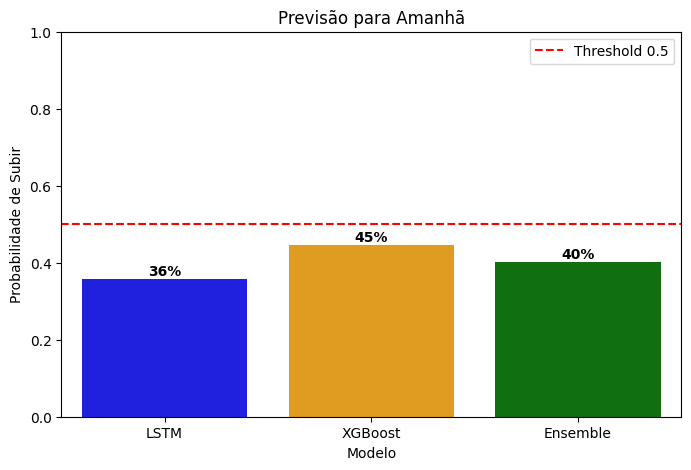

In [20]:
import seaborn as sns

# Opção 2 — Previsão do último dia
categorias     = ['LSTM', 'XGBoost', 'Ensemble']
probabilidades = [prob_lstm[-1], prob_xgb[-1], prob_final[-1]]

# Seaborn trabalha melhor com DataFrame
df_plot = pd.DataFrame({
    "Modelo": categorias,
    "Probabilidade": probabilidades
})

# Gráfico
plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x="Modelo", y="Probabilidade", hue="Modelo", legend=False,
            palette=["blue", "orange", "green"])

# Threshold
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold 0.5')

# Valor em cima de cada barra
for i, v in enumerate(probabilidades):
    plt.text(i, v + 0.01, f"{v:.0%}", ha="center", fontweight="bold")

plt.title("Previsão para Amanhã")
plt.xlabel("Modelo")
plt.ylabel("Probabilidade de Subir")
plt.legend()
plt.ylim(0, 1)
plt.show()

In [21]:
df_backtest_list = []

for ticker in df['ticker'].unique():
    df_t = df[df['ticker'] == ticker].copy()
    df_t = df_t.iloc[:-1]

    val_end = int(len(df_t) * 0.70)
    df_te = df_t.iloc[val_end:].copy()
    df_backtest_list.append(df_te)

df_backtest = pd.concat(df_backtest_list).reset_index(drop=True)

df_backtest = df_backtest.groupby('ticker').apply(
    lambda x: x.iloc[60:]
).reset_index(drop=True)

print(df_backtest.shape)
print(y_test_lstm.shape)

(5855, 26)
(5855,)


/tmp/ipykernel_2303/1071811085.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_backtest = df_backtest.groupby('ticker').apply(


In [38]:
df_backtest['previsao'] = previsao_final
reducao = 0.3

df_backtest['retorno_modelo'] = df_backtest.apply(
    lambda x: x['return_1'] if x['previsao'] == 1 else x['return_1'] * reducao, axis=1
)

# Curva de capital por ticker
for ticker in df_backtest['ticker'].unique():
    df_t = df_backtest[df_backtest['ticker'] == ticker].copy()

    capital_modelo  = (1 + df_t['retorno_modelo']).cumprod().iloc[-1]
    capital_buyhold = (1 + df_t['return_1']).cumprod().iloc[-1]

    print(f"{ticker} | Modelo: {capital_modelo:.2f}x | Buy&Hold: {capital_buyhold:.2f}x")

AAPL | Modelo: 2.49x | Buy&Hold: 14.02x
AMZN | Modelo: 1.44x | Buy&Hold: 8.14x
GOOGL | Modelo: 1.99x | Buy&Hold: 10.21x
MSFT | Modelo: 1.88x | Buy&Hold: 7.15x
NVDA | Modelo: 3.05x | Buy&Hold: 93.75x


## Salvando os modelos

* Modelo LSTM
* Modelo XGboost
* Técnica de Normalização
* Técnica Ensemble

In [49]:
import joblib
import os

# Cria pasta para os modelos
os.makedirs("models", exist_ok=True)

# 1. Salva o XGBoost
joblib.dump(modelo_xgb, "models/xgboost_model.pkl")
print("XGBoost salvo!")

# 2. Salva o LSTM
modelo_lstm.save("models/lstm_model.keras")
print("LSTM salvo!")

# 3. Salva o Scaler
scalers = {}

for ticker in df['ticker'].unique():
    df_t = df[df['ticker'] == ticker].copy()
    df_t = df_t.iloc[:-1]

    X_t = df_t.drop(columns=column_drop).values
    train_end = int(len(X_t) * 0.60)
    X_tr = X_t[:train_end]

    scaler = StandardScaler()
    scaler.fit(X_tr)
    scalers[ticker] = scaler

joblib.dump(scalers, "models/scalers.pkl")
print("Scalers salvos!")

# Salva o Ensemble
ensemble_config = {
    "lookback": lookback,
    "threshold": 0.4,
    "peso_lstm": 0.7,
    "peso_xgb": 0.3,
    "features": list(df.drop(columns=['Date', 'ticker', 'target', 'Close']).columns),
    "tickers": list(df['ticker'].unique()),
    "data_treino": "2010-2021",
    "data_val": "2022-2023",
    "data_teste": "2023-2024"
}

import json
with open("models/ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=4)
print("Config salva!")

XGBoost salvo!
LSTM salvo!
Scalers salvos!
Config salva!
